epoch: 0 loss: 109.25792035720488
epoch: 50 loss: 7.421994879643963
epoch: 100 loss: 6.506622807527913
epoch: 150 loss: 6.342148839217396
epoch: 200 loss: 6.196471479605406
epoch: 250 loss: 6.065019913603256
epoch: 300 loss: 5.945933896357212
epoch: 350 loss: 5.83786393632981
epoch: 400 loss: 5.739755102581352
epoch: 450 loss: 5.650737689963453

Test MSE: 5.708656175215754
Test RMSE: 2.389279425939075


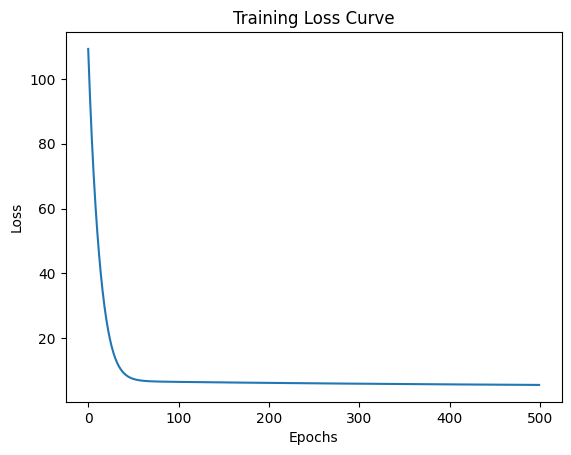

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

np.random.seed(42)

cols = [
"Sex","Length","Diameter","Height","WholeWeight",
"ShuckedWeight","VisceraWeight","ShellWeight","Rings"
]

data = pd.read_csv("abalone.data", names=cols)

data = pd.get_dummies(data, columns=["Sex"])

X = data.drop("Rings", axis=1).values
y = data["Rings"].values.reshape(-1,1)

X_train, X_test, y_train, y_test = train_test_split(
X,y,test_size=0.2,random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

input_size = X_train.shape[1]
hidden_size = 12
output_size = 1

W1 = np.random.randn(input_size, hidden_size)*0.01
b1 = np.zeros((1,hidden_size))

W2 = np.random.randn(hidden_size, output_size)*0.01
b2 = np.zeros((1,output_size))

def sigmoid(x):
    return 1/(1+np.exp(-x))

def sigmoid_derivative(a):
    return a*(1-a)

epochs = 500
lr = 0.01

losses = []

for epoch in range(epochs):

    z1 = np.dot(X_train,W1)+b1
    a1 = sigmoid(z1)

    z2 = np.dot(a1,W2)+b2
    y_pred = z2

    loss = np.mean((y_pred-y_train)**2)
    losses.append(loss)

    dz2 = (y_pred-y_train)

    dW2 = np.dot(a1.T,dz2)/X_train.shape[0]
    db2 = np.sum(dz2,axis=0,keepdims=True)/X_train.shape[0]

    dz1 = np.dot(dz2,W2.T)*sigmoid_derivative(a1)

    dW1 = np.dot(X_train.T,dz1)/X_train.shape[0]
    db1 = np.sum(dz1,axis=0,keepdims=True)/X_train.shape[0]

    W2 -= lr*dW2
    b2 -= lr*db2

    W1 -= lr*dW1
    b1 -= lr*db1

    if epoch%50==0:
        print("epoch:",epoch,"loss:",loss)

z1 = np.dot(X_test,W1)+b1
a1 = sigmoid(z1)

z2 = np.dot(a1,W2)+b2
y_pred_test = z2

mse = mean_squared_error(y_test,y_pred_test)
rmse = np.sqrt(mse)

print("\nTest MSE:",mse)
print("Test RMSE:",rmse)

plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()